In [2]:
import torch
import matplotlib.pyplot as plt 

%matplotlib inline

In [3]:
names = open("./names.txt", "r").read().splitlines()
print(f"first 8 names: {names[:8]},\ntotal names:{len(names)}")

first 8 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'],
total names:32033


In [4]:
# build the vocabulary of characters and map to/from integers 
characters = sorted(set("".join(names)))
stoi = {c:i+1 for i, c in enumerate(characters)}
stoi["."] = 0
itos = {i:c for c, i in stoi.items()}
total_unique_chars_in_dataset = len(itos)

In [5]:
# build the dataset

BLOCK_SIZE = 3 # CONTEXT LENGTH: how many characters do we take to predict next ?
X,Y = [],[]

for w in names[:13]:
    
    context = [0] * BLOCK_SIZE
    print("\n", w)
    
    for ch in (w +"."):
        
        ix = stoi[ch]
        X.append(context) 
        Y.append(ix)
        
        print(f"{"".join([itos[i] for i in context])} -> {itos[ix]}")
        
        context = context[1:]+ [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
        
        


 emma
... -> e
..e -> m
.em -> m
emm -> a
mma -> .

 olivia
... -> o
..o -> l
.ol -> i
oli -> v
liv -> i
ivi -> a
via -> .

 ava
... -> a
..a -> v
.av -> a
ava -> .

 isabella
... -> i
..i -> s
.is -> a
isa -> b
sab -> e
abe -> l
bel -> l
ell -> a
lla -> .

 sophia
... -> s
..s -> o
.so -> p
sop -> h
oph -> i
phi -> a
hia -> .

 charlotte
... -> c
..c -> h
.ch -> a
cha -> r
har -> l
arl -> o
rlo -> t
lot -> t
ott -> e
tte -> .

 mia
... -> m
..m -> i
.mi -> a
mia -> .

 amelia
... -> a
..a -> m
.am -> e
ame -> l
mel -> i
eli -> a
lia -> .

 harper
... -> h
..h -> a
.ha -> r
har -> p
arp -> e
rpe -> r
per -> .

 evelyn
... -> e
..e -> v
.ev -> e
eve -> l
vel -> y
ely -> n
lyn -> .

 abigail
... -> a
..a -> b
.ab -> i
abi -> g
big -> a
iga -> i
gai -> l
ail -> .

 emily
... -> e
..e -> m
.em -> i
emi -> l
mil -> y
ily -> .

 elizabeth
... -> e
..e -> l
.el -> i
eli -> z
liz -> a
iza -> b
zab -> e
abe -> t
bet -> h
eth -> .


In [6]:
print(f"{X=}\n\n{Y=}")

X=tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  3],
        [ 0,  3,  8],
        [ 3,  8,  1],
        [ 8,  1, 18],
        [ 1, 18, 12],
        [18, 12, 15],
        [12, 15, 20],
        [15, 20, 20],
        [20, 20,  5],
        [ 0,  0,  0],
        [ 0,  0, 13],
        [ 0, 13,  9],
        

In [7]:
print(f"X: {X.shape, X.dtype, X.dim()}")
print(f"Y: {Y.shape, Y.dtype, Y.dim()}")
print(f"{X=}\n\n{Y=}\n")

X: (torch.Size([91, 3]), torch.int64, 2)
Y: (torch.Size([91]), torch.int64, 1)
X=tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  3],
        [ 0,  3,  8],
        [ 3,  8,  1],
        [ 8,  1, 18],
        [ 1, 18, 12],
        [18, 12, 15],
        [12, 15, 20],
        [15, 20, 20],
        [20, 20, 

In [8]:
# Embedding Lookup Table
embedding_dim = 2
C = torch.randn((total_unique_chars_in_dataset, embedding_dim))

emb = C[X] # C tensor can be indexed or access by directly given tensor or list into 
print(f"{emb.shape=},\n{C.shape=}\n{emb=},\n{C=}")
print(f"{C[0]=}, {C[0,0]=}, {emb[0]=}, {emb[0,0]=}, {emb[0,0,0]=}")


emb.shape=torch.Size([91, 3, 2]),
C.shape=torch.Size([27, 2])
emb=tensor([[[-0.0989, -0.3462],
         [-0.0989, -0.3462],
         [-0.0989, -0.3462]],

        [[-0.0989, -0.3462],
         [-0.0989, -0.3462],
         [-0.5700,  0.5199]],

        [[-0.0989, -0.3462],
         [-0.5700,  0.5199],
         [ 0.1801,  2.0518]],

        [[-0.5700,  0.5199],
         [ 0.1801,  2.0518],
         [ 0.1801,  2.0518]],

        [[ 0.1801,  2.0518],
         [ 0.1801,  2.0518],
         [ 0.5639, -1.0162]],

        [[-0.0989, -0.3462],
         [-0.0989, -0.3462],
         [-0.0989, -0.3462]],

        [[-0.0989, -0.3462],
         [-0.0989, -0.3462],
         [-0.1722,  0.6762]],

        [[-0.0989, -0.3462],
         [-0.1722,  0.6762],
         [-1.7954,  0.6564]],

        [[-0.1722,  0.6762],
         [-1.7954,  0.6564],
         [ 1.9643, -0.2302]],

        [[-1.7954,  0.6564],
         [ 1.9643, -0.2302],
         [ 0.4923, -0.0088]],

        [[ 1.9643, -0.2302],
         [ 0.49

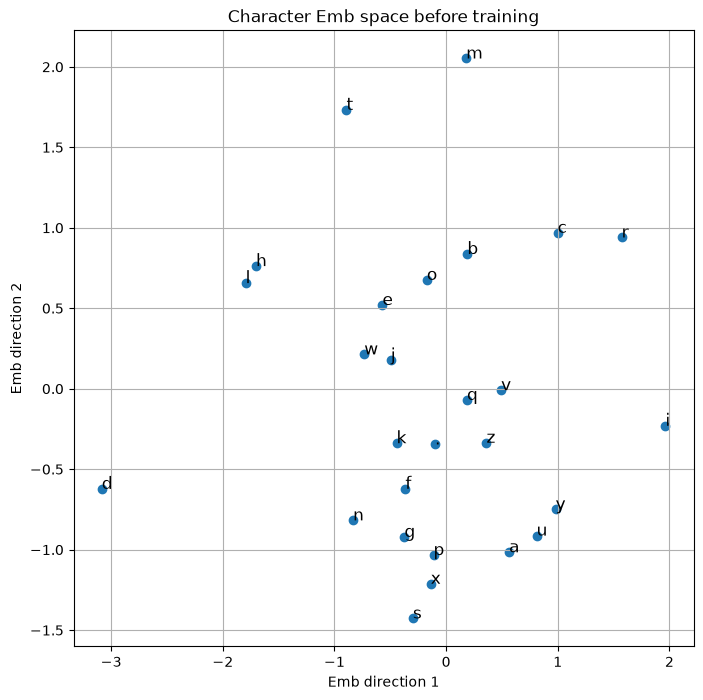

In [17]:
from word_generator.chart import plot2d_embedded_characters
plot2d_embedded_characters(
    EMBEDDING_TABLE=C, 
    itos=itos, xlabel="Emb direction 1", 
    ylabel="Emb direction 2", 
    title="Character Emb space before training" 
)

In [10]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [11]:
W1.shape, b1.shape, emb.shape

(torch.Size([6, 100]), torch.Size([100]), torch.Size([91, 3, 2]))

In [12]:
# cast emb to be multiplied by w1 
y_ = emb.view(-1, 6) @ W1 + b1
y_

tensor([[-1.1164,  0.2399, -1.6362,  ...,  2.3638, -2.2918, -0.8074],
        [-1.3712,  1.9941, -1.7522,  ...,  3.3111, -3.2168, -2.2994],
        [ 0.0816,  5.2996, -2.1095,  ...,  2.0707, -4.2996, -3.2959],
        ...,
        [-0.7763,  3.0442, -1.0460,  ...,  3.2260, -1.5875, -5.3878],
        [-3.4237,  3.9905, -0.0677,  ...,  4.5767, -4.0519, -3.5271],
        [-4.7026,  5.3804,  1.0412,  ...,  4.2915, -1.9295, -5.8544]])

In [13]:
# activation 
h = torch.tanh(y_)
h.shape

torch.Size([91, 100])

In [14]:
W2 = torch.randn(W1.shape[1], 150)
b2 = torch.randn(W2.shape[1])

In [15]:
logits = h @ W2 + b2 
logits

tensor([[ -0.5525,  -4.8716,   7.4428,  ...,  10.5631,  -1.7709,  -7.7068],
        [ -0.3491,  -6.7544,   6.8037,  ...,   6.5434,  -9.5214,  -6.0893],
        [ -6.0967,   0.8079,   8.0079,  ...,  13.7212,   2.2616,  -4.1751],
        ...,
        [ 11.6522,  -4.8386,   1.4171,  ...,   4.5073,   7.2201,  -7.2655],
        [ -8.6868,  -4.4756,   6.1201,  ...,   0.6686,  -8.4998,  -7.5491],
        [ -5.4711,  -7.5843,   0.3329,  ...,   2.0527,  -2.3389, -19.8625]])

In [16]:
# loss: negative log-likehood 
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True)
loss1 = -probs[torch.arange(emb.shape[0]), Y].log().mean()


"""loss : nll 
this is mathematically handled and calculated by :
 -> torch.nn.functional.cross_entropy() 
    it properly handles extreme cases infinite, none, etc 
"""
loss2 = torch.nn.functional.cross_entropy(logits, Y)

print(f"{loss1=}, {loss2=}")

loss1=tensor(24.6700), loss2=tensor(24.6700)
